In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
import sys

sys.path.append("..")

import torch
import numpy as np
import matplotlib.pyplot as plt

## Data visualization

In [4]:
filename2 = "K15"

In [5]:
# set working dir
directory = "/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2"
# Input file names
filename = "Poten00000200"

path = os.path.join(directory, filename)

# load data files
time = np.loadtxt(os.path.join(directory, "time.dat"))
sgrid = np.loadtxt(os.path.join(directory, "sgrid"))
xphi = np.loadtxt(os.path.join(directory, "xphi"))
yphi = np.loadtxt(os.path.join(directory, "yphi"))
fluxes = np.loadtxt(os.path.join(directory, "fluxes.dat"))
kyspec = np.loadtxt(os.path.join(directory, "kyspec"))
krho = np.loadtxt(os.path.join(directory, "krho"))
vpgr = np.loadtxt(os.path.join(directory, "vpgr.dat"))
vperp = np.loadtxt(os.path.join(directory, "vperp.dat"))

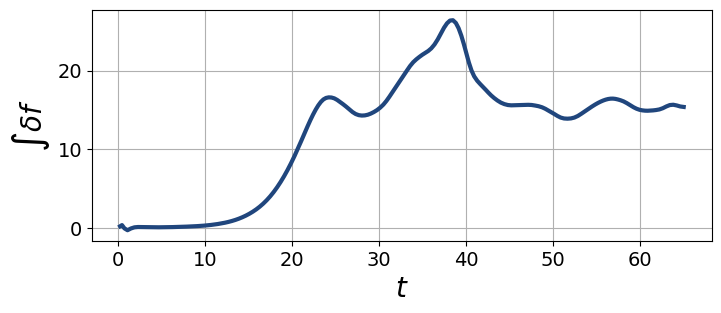

In [8]:
# number of parallel direction grid points
ns = sgrid.shape[1] if len(sgrid.shape) > 1 else sgrid.shape[0]

# number of x, y grid points (in real space)
nx, ny = xphi.shape[1], xphi.shape[0]

# number of modes in x and y direction
nkx, nky = krho.shape[1], krho.shape[0]

# get velocity space resolutions
nvpar, nmu = vpgr.shape[1], vpgr.shape[0]

# Plot flux trace
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(time[0:180], fluxes[0:180, 1], lw=3, c=(32 / 255, 70 / 255, 125 / 255))
ax.grid()
ax.set_xlabel(r"$t$", fontsize=20)
ax.set_ylabel(r"$\int \delta f$", fontsize=20)
ax.tick_params(labelsize=14)

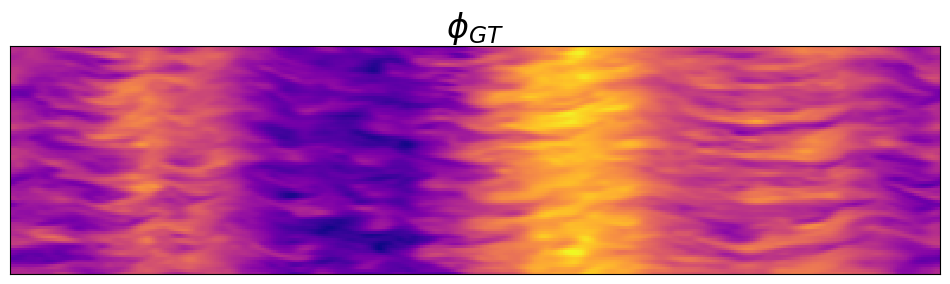

In [12]:
from matplotlib import colormaps


c_map = colormaps["plasma"]

# number of parallel direction grid points
ns = sgrid.shape[1] if len(sgrid.shape) > 1 else sgrid.shape[0]

# number of x, y grid points (in real space)
nx, ny = xphi.shape[1], xphi.shape[0]

# number of modes in x and y direction
nkx, nky = krho.shape[1], krho.shape[0]

# get velocity space resolutions
nvpar, nmu = vpgr.shape[1], vpgr.shape[0]

# load real space electric potential data
filename = "Poten00000380"
a = np.loadtxt(os.path.join(directory, filename))
phi = np.reshape(a, (nx, ns, ny), order="F")

# Plot real space potential
fig, ax = plt.subplots(1, 1, figsize=(12, 3))

filename = "Poten00000400"
a = np.loadtxt(os.path.join(directory, filename))
phi = np.reshape(a, (nx, ns, ny), order="F")
ax.matshow(np.squeeze(phi[:, 8, :]).T, cmap=c_map)
ax.set_title(r"$\phi_{GT}$", fontsize=24)
ax.set_xticks([])
ax.set_yticks([])
fig.savefig("potentials.svg", bbox_inches="tight")

In [ ]:
# number of parallel direction grid points
ns = sgrid.shape[1] if len(sgrid.shape) > 1 else sgrid.shape[0]

# number of x, y grid points (in real space)
nx, ny = xphi.shape[1], xphi.shape[0]

# number of modes in x and y direction
nkx, nky = krho.shape[1], krho.shape[0]

# get velocity space resolutions
nvpar, nmu = vpgr.shape[1], vpgr.shape[0]

# load real space electric potential data
a = np.loadtxt(os.path.join(directory, filename))
phi = np.reshape(a, (nx, ns, ny))

# Plot real space potential
plt.figure()
plt.pcolor(xphi, yphi, np.squeeze(phi[:, 8, :]).T, shading="auto")
plt.colorbar()
plt.title("Real Space Potential")
plt.xlabel("xphi")
plt.ylabel("yphi")
plt.show()
plt.savefig("potentials.svg")

# Plot flux trace
plt.figure()
plt.plot(time, fluxes[:, 1])
plt.title("Flux Trace")
plt.xlabel("Time")
plt.ylabel("Fluxes")
plt.show()
plt.savefig("fluxes.svg")

# Load full distribution function data
with open(os.path.join(directory, filename2), "rb") as fid:
    ff = np.fromfile(fid, dtype=np.float64)

# Reshape the distribution function (first index is re/im component of fourier weights)
f = np.reshape(ff, (2, nvpar, nmu, ns, nkx, nky), order="F")

# Plot distribution function in velocity space
plt.figure()
plt.pcolor(vpgr, vperp, np.squeeze(f[0, :, :, 8, 80, 20]).T, shading="auto")
plt.colorbar()
plt.title("Distribution Function (Velocity Space)")
plt.xlabel("vpgr")
plt.ylabel("vperp")
plt.show()

# Additional plot of the distribution function
plt.figure()
plt.pcolor(np.squeeze(f[0, :, 2, :, 80, 20]).T, shading="auto")
plt.colorbar()
plt.title("Distribution Function Slice")
plt.show()

In [8]:
import os
import numpy as np
import torch

import matplotlib
import matplotlib.ticker as tkr


directory = "/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2"


def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def plot4x4_sided4times(x1, x2, x3, x4, average=True):
    labels = [r"v_{par}", r"v_{\mu}", r"s", r"k_x", r"k_y"]
    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(36, 20))
    for i in range(5):
        for j in range(5):
            if j == 0 or i == 4:
                ax[i, j].remove()
                continue
            ax_ij = ax[i, j]
            ax_ij.set_frame_on(False)
            ax_ij.tick_params(labelleft=False, labelbottom=False)
            ax_ij.set_xticks([])
            ax_ij.set_yticks([])

    c_map = matplotlib.colormaps["RdBu"]

    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])

        if average:
            x1_plot = x1[0].mean(other)
            x2_plot = x2[0].mean(other)
            x3_plot = x3[0].mean(other)
            x4_plot = x4[0].mean(other)
        else:
            x1_plot = x1[0].permute(i, j, *other).numpy()
            x1_plot = x1_plot[
                :,
                :,
                x1_plot.shape[2] // 2,
                x1_plot.shape[3] // 2,
                x1_plot.shape[4] // 2,
            ]
            x2_plot = x2[0].permute(i, j, *other).numpy()
            x2_plot = x2_plot[
                :,
                :,
                x2_plot.shape[2] // 2,
                x2_plot.shape[3] // 2,
                x2_plot.shape[4] // 2,
            ]
            x3_plot = x3[0].permute(i, j, *other).numpy()
            x3_plot = x3_plot[
                :,
                :,
                x3_plot.shape[2] // 2,
                x3_plot.shape[3] // 2,
                x3_plot.shape[4] // 2,
            ]
            x4_plot = x4[0].permute(i, j, *other).numpy()
            x4_plot = x4_plot[
                :,
                :,
                x4_plot.shape[2] // 2,
                x4_plot.shape[3] // 2,
                x4_plot.shape[4] // 2,
            ]

        ax_ij = ax[i, j]
        pos = ax_ij.get_position()

        # Define the positions for four subplots in a 2x2 layout
        plot_width = 0.45 * pos.width
        plot_height = 0.45 * pos.height
        x_left_1 = pos.x0
        x_left_2 = x_left_1 + plot_width
        y_bottom_1 = pos.y0
        y_bottom_2 = y_bottom_1 + plot_height

        ax1 = fig.add_axes([x_left_1, y_bottom_2, plot_width, plot_height])  # Top-left
        ax2 = fig.add_axes([x_left_2, y_bottom_2, plot_width, plot_height])  # Top-right
        ax3 = fig.add_axes(
            [x_left_1, y_bottom_1, plot_width, plot_height]
        )  # Bottom-left
        ax4 = fig.add_axes(
            [x_left_2, y_bottom_1, plot_width, plot_height]
        )  # Bottom-right

        # Compute shared vmin and vmax
        vmin = min(x1_plot.min(), x2_plot.min(), x3_plot.min(), x4_plot.min())
        vmax = max(x1_plot.max(), x2_plot.max(), x3_plot.max(), x4_plot.max())

        im1 = ax1.matshow(x1_plot, cmap=c_map, vmin=vmin, vmax=vmax)
        im2 = ax2.matshow(x2_plot, cmap=c_map, vmin=vmin, vmax=vmax)
        im3 = ax3.matshow(x3_plot, cmap=c_map, vmin=vmin, vmax=vmax)
        im4 = ax4.matshow(x4_plot, cmap=c_map, vmin=vmin, vmax=vmax)

        # Shared colorbar
        cbar = fig.colorbar(
            im1, ax=[ax_ij], format=tkr.FormatStrFormatter("%.2g"), pad=0, fraction=0.05
        )
        cbar.set_ticks([vmin, (vmin + vmax) / 2, vmax])
        cbar.ax.tick_params(labelsize=12)

        if i == 0:
            ax1.set_title("ZF (0)", fontsize=18)
            ax2.set_title("[1:10]", fontsize=18)
            ax3.set_title("[11:20]", fontsize=18)
            ax4.set_title("[21:31]", fontsize=18)

        if j == 1 or (i == 1 and j == 2) or (i == 2 and j == 3) or (i == 3 and j == 4):
            ax_ij.set_ylabel(rf"${labels[i]}$", fontsize=14)

        if i == 3 or j == 1 or (i == 1 and j == 2) or (i == 2 and j == 3):
            ax_ij.set_xlabel(rf"${labels[j]}$", fontsize=14)

        # Remove axis ticks and labels
        for axx in [ax1, ax2, ax3, ax4]:
            axx.set_xticks([])
            axx.set_yticks([])
            axx.tick_params(labelleft=False, labelbottom=False)
            force_aspect(axx)

    return fig


def plot4x4_sided(x1, x2, mark_bad=False, average=True):
    labels = [r"v_{par}", r"v_{\mu}", r"s", r"k_x", r"k_y"]
    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(30, 14))
    for i in range(5):
        for j in range(5):
            if j == 0:
                ax[i, j].remove()
                continue
            if i == 4:
                ax[i, j].remove()
                continue
            ax_ij = ax[i, j]
            ax_ij.set_frame_on(False)
            ax_ij.tick_params(labelleft=False, labelbottom=False)
            ax_ij.set_xticks([])
            ax_ij.set_yticks([])

    c_map = matplotlib.colormaps["RdBu"]
    c_map.set_bad("k")

    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])

        if average:
            x1_plot = x1[0].mean(other)
            x2_plot = x2[0].mean(other)
        else:
            x1_plot = x1[0].permute(i, j, *other).numpy()[:, :, 0, 0, 0]
            x2_plot = x2[0].permute(i, j, *other).numpy()[:, :, 0, 0, 0]

        if mark_bad:
            x1_std = x1.std(other)
            x2_std = x2.std(other)
            x1_plot[x1_std == 0] = np.nan
            x2_plot[x2_std == 0] = np.nan

        ax_ij = ax[i, j]
        pos = ax_ij.get_position()

        # create two new axes within the same space as the original subplot
        plot_width = 0.475 * pos.width
        left_margin = 0.0 * pos.width
        x_left_1 = pos.x0 + left_margin
        x_left_2 = x_left_1 + plot_width
        y = pos.y0
        h = pos.height
        ax1 = fig.add_axes([x_left_1, y, plot_width, h])
        ax2 = fig.add_axes([x_left_2, y, plot_width, h])

        # compute shared vmin and vmax
        vmin = min(x1_plot.min(), x2_plot.min())
        vmax = max(x1_plot.max(), x2_plot.max())

        im1 = ax1.matshow(x1_plot, cmap=c_map, vmin=vmin, vmax=vmax)
        ax2.matshow(x2_plot, cmap=c_map, vmin=vmin, vmax=vmax)

        # shared colourbar
        cbar = fig.colorbar(
            im1, ax=[ax_ij], format=tkr.FormatStrFormatter("%.2g"), pad=0, fraction=0.05
        )
        cbar.set_ticks([vmin, (vmin + vmax) / 2, vmax])
        cbar.ax.tick_params(labelsize=12)

        if i == 0:
            # Set axis labels
            ax1.set_title("ZF", fontsize=24)
            ax2.set_title("TURB", fontsize=24)

        if j == 1 or (i == 1 and j == 2) or (i == 2 and j == 3) or (i == 3 and j == 4):
            ax_ij.set_ylabel(rf"${labels[i]}$", fontsize=14)

        if i == 3 or j == 1 or (i == 1 and j == 2) or (i == 2 and j == 3):
            ax_ij.set_xlabel(rf"${labels[j]}$", fontsize=14)

        # Remove axis ticks and labels
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax2.set_xticks([])
        ax2.set_yticks([])
        ax1.tick_params(labelleft=False, labelbottom=False)
        ax2.tick_params(labelleft=False, labelbottom=False)
        # Force aspect ratio
        force_aspect(ax1)
        force_aspect(ax2)

    return fig


def frequency_filter_4x4(fname, mode="mean", filter_method="fft"):
    # load data files
    sgrid = np.loadtxt(os.path.join(directory, "sgrid"))
    krho = np.loadtxt(os.path.join(directory, "krho"))
    vpgr = np.loadtxt(os.path.join(directory, "vpgr.dat"))
    ns = sgrid.shape[1] if len(sgrid.shape) > 1 else sgrid.shape[0]

    nkx, nky = krho.shape[1], krho.shape[0]
    nvpar, nmu = vpgr.shape[1], vpgr.shape[0]

    with open(os.path.join(directory, fname), "rb") as fid:
        ff = np.fromfile(fid, dtype=np.float64)

    x = (
        np.reshape(ff, (2, nvpar, nmu, ns, nkx, nky), order="F")
        .copy()
        .astype("float32")
    )

    def do_ifft(x, sl=None):
        x = np.ascontiguousarray(np.moveaxis(x, 0, -1))
        x = x.view(dtype=np.complex64)
        x = np.fft.fftshift(x, axes=(3, 4))
        if sl is not None:
            x[..., sl, :] = 0.0
        x = np.fft.ifftn(x, axes=(3, 4))
        x = np.stack([x.real, x.imag]).squeeze().astype("float32")
        return torch.from_numpy(x)

    if filter_method == "fft":

        x_zf = do_ifft(x.copy(), np.arange(1, 32))
        x_turb1 = do_ifft(x.copy(), [0] + list(range(11, 32)))
        x_turb2 = do_ifft(x.copy(), list(range(0, 10)) + list(range(22, 32)))
        x_turb3 = do_ifft(x.copy(), list(range(0, 22)))

    if filter_method == "gauss":
        from scipy.ndimage import gaussian_filter

        x = do_ifft(x)
        x = x / x.std()
        # apply separate on real / imag
        x_zf = x.copy()
        x_zf[0] = gaussian_filter(x_zf[0], sigma=(2.0, 2.0, 2.0, 4.5, 4.5))
        # x_zf[1] = gaussian_filter(x_zf[1], sigma=0.3)

        x_turb2 = x.copy()
        x_turb2[0] = gaussian_filter(x_turb2[0], sigma=(0.3, 0.3, 0.3, 0.8, 0.8))
        # x_turb2[1] = gaussian_filter(x_turb2[1], sigma=2.0)

        # band pass via gaussian difference
        x_turb1 = x - x_zf - x_turb2
        x_turb3 = x_zf + x_turb1 + x_turb2

    return plot4x4_sided4times(
        x_zf[0][None],
        x_turb1[0][None],
        x_turb2[0][None],
        x_turb3[0][None],
        average=(mode == "mean"),
    )

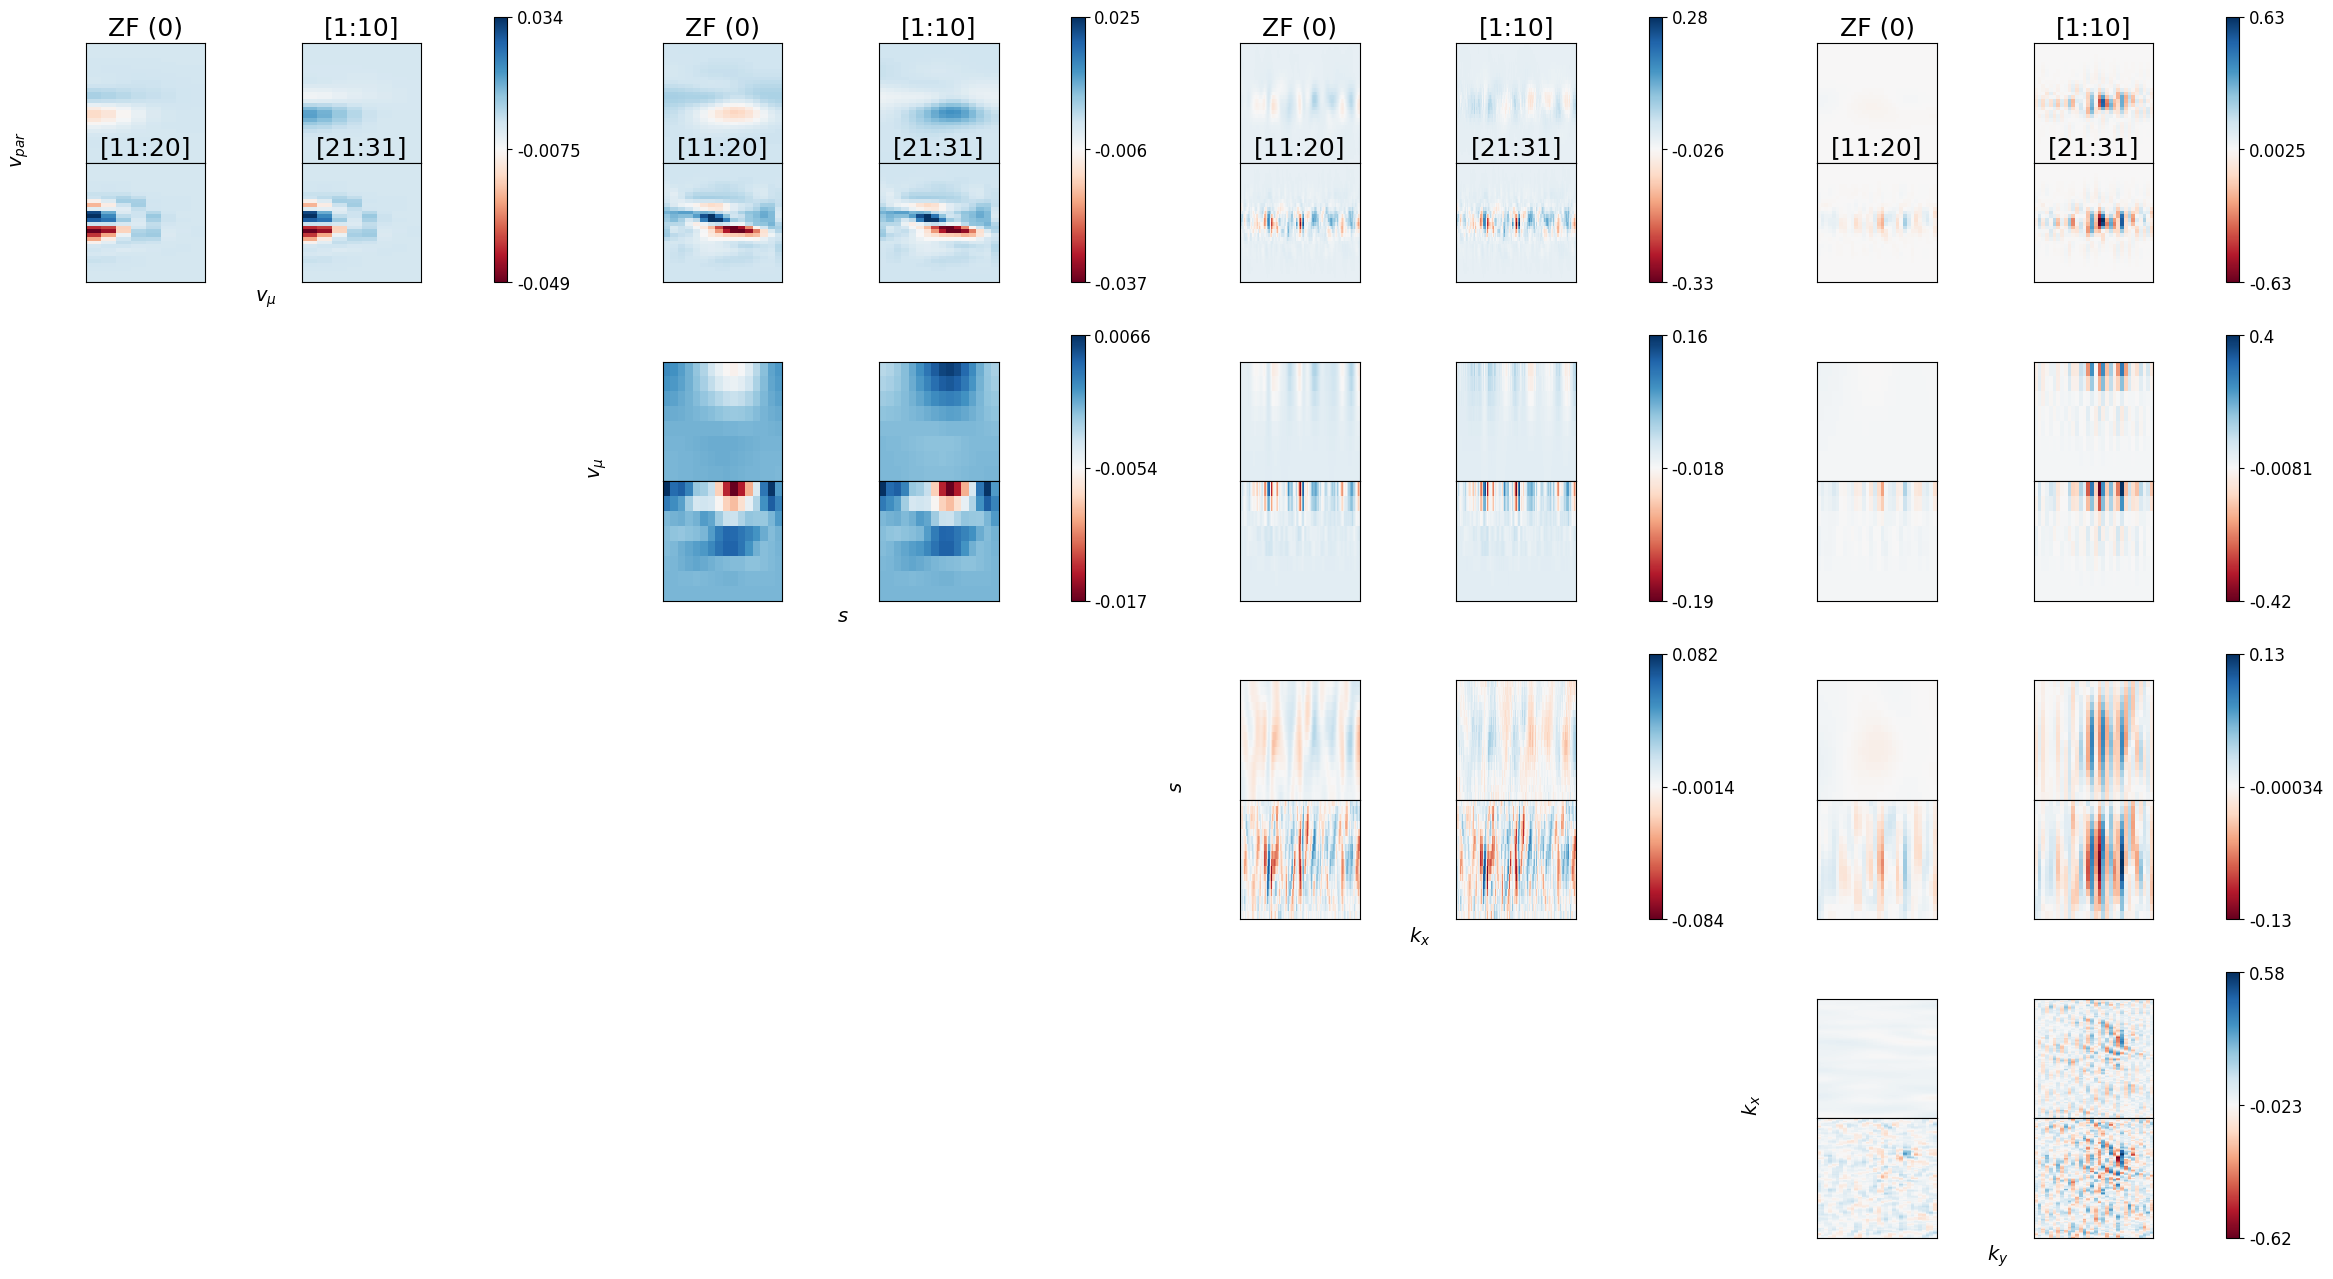

In [83]:
_ = frequency_filter_4x4("K50", mode="mean", filter_method="gauss")

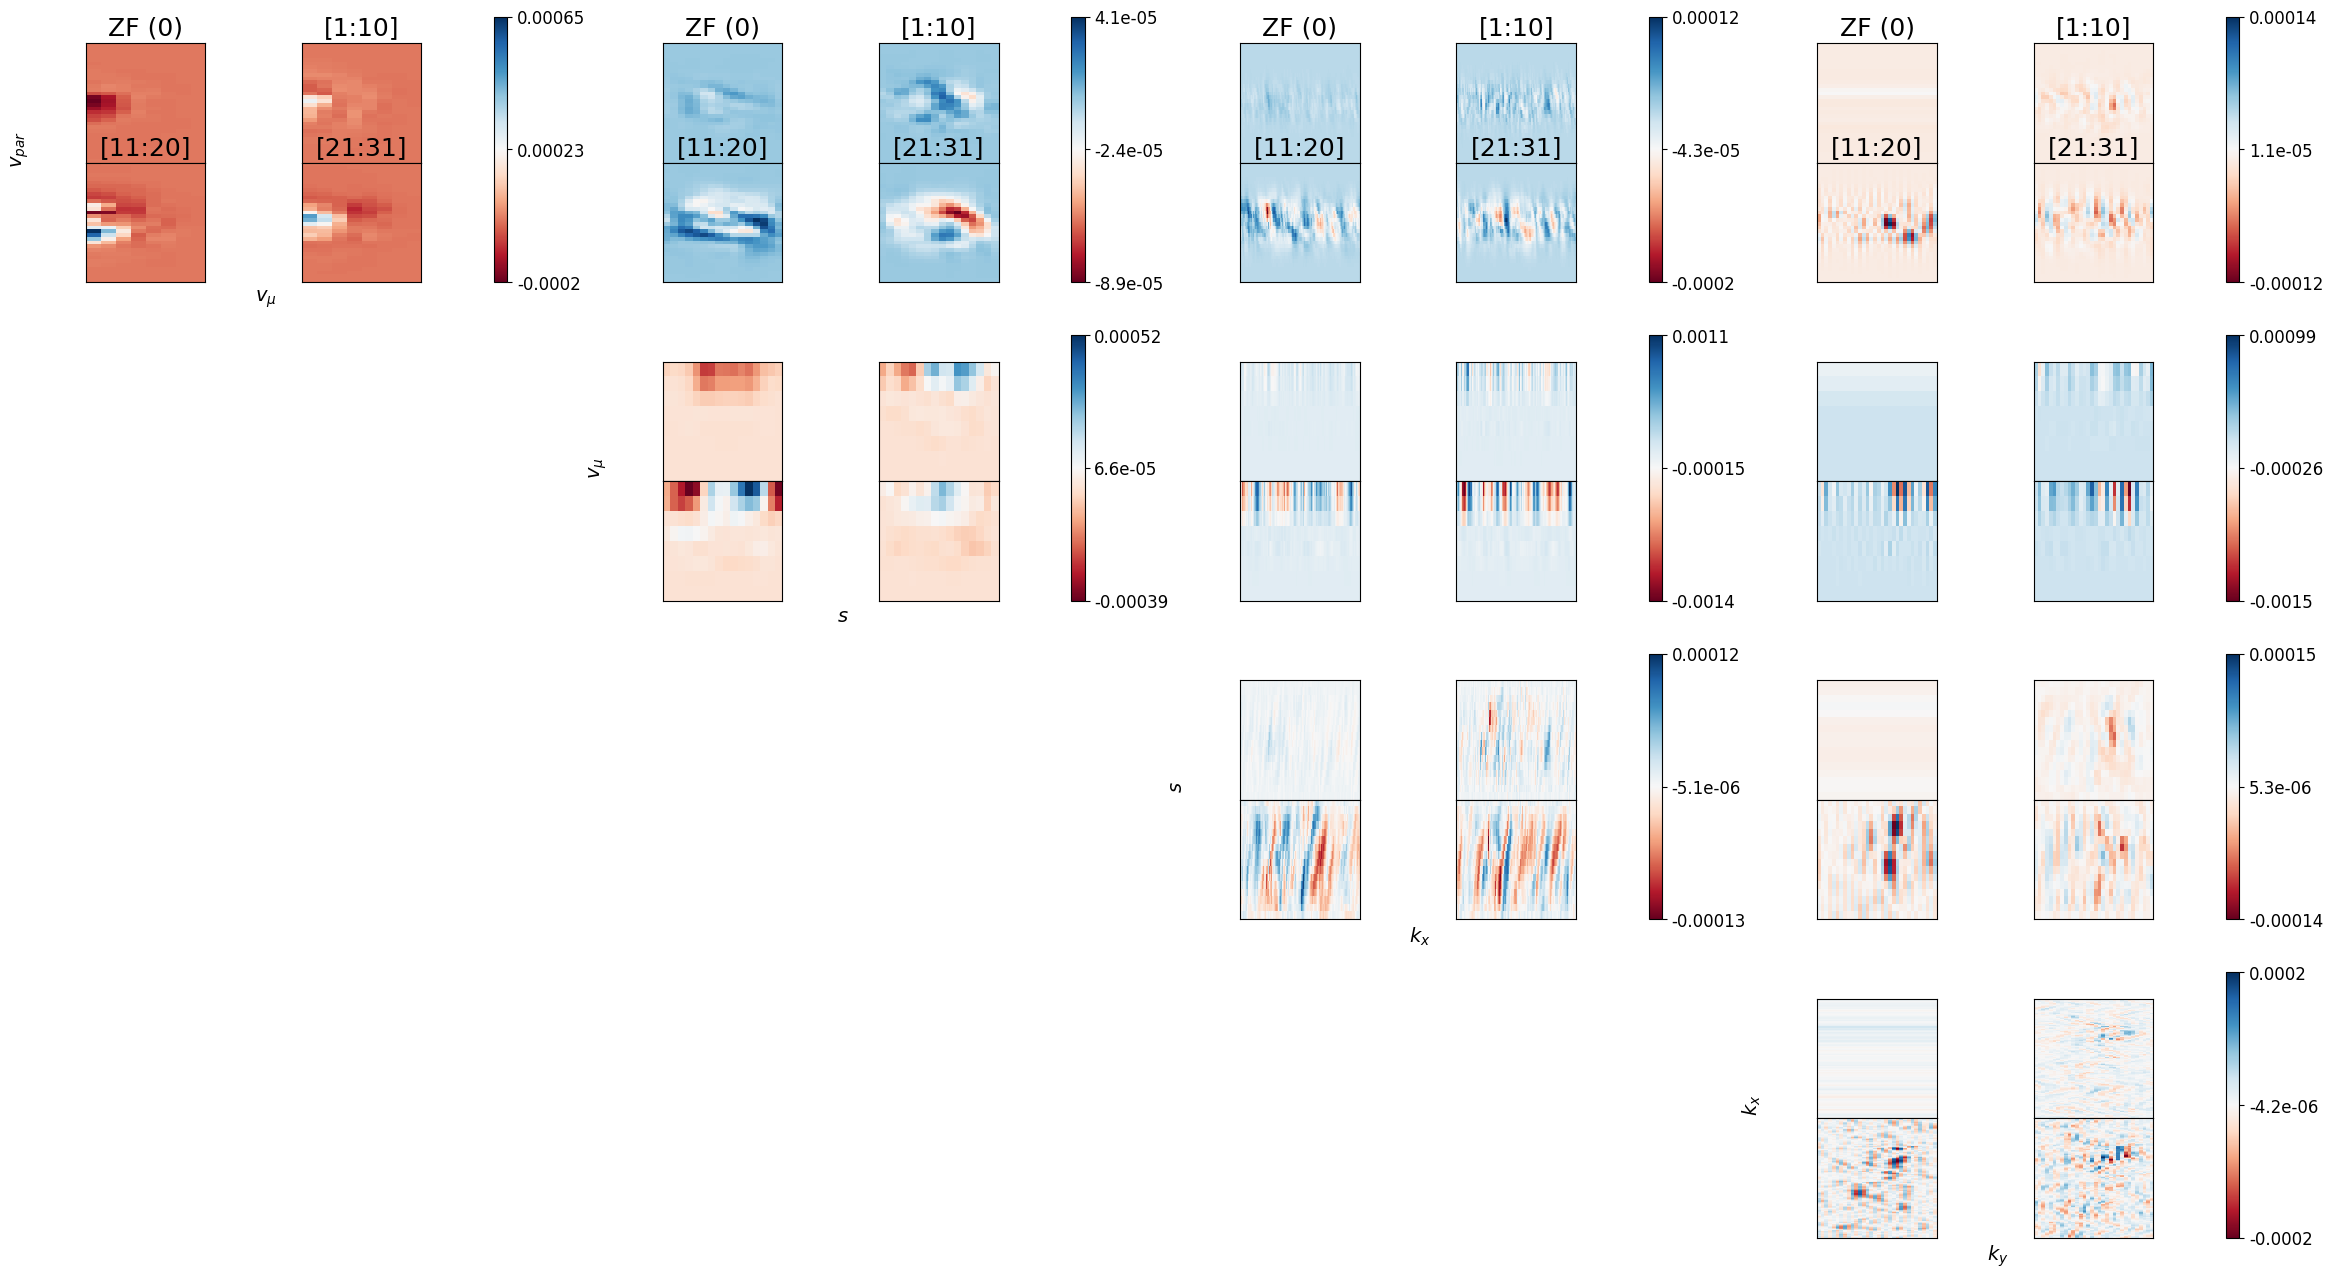

In [9]:
_ = frequency_filter_4x4("K50", mode="slice", filter_method="fft")

In [234]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def plot4x4_3D(x, title="", mode="mean"):
    labels = [r"v_{par}", r"v_{\mu}", r"s", r"k_x", r"k_y"]
    comb = torch.combinations(torch.arange(5), 3).tolist()

    fig = plt.figure(figsize=(24, 18))
    fig.suptitle(title)

    cmap = "RdBu_r"

    for idx, (i, j, k) in enumerate(comb):
        ax_main = fig.add_subplot(4, 4, idx + 1, projection="3d")
        other = tuple([o for o in range(5) if o != i and o != j and o != k])

        if mode == "mean":
            xx = x.mean(other)
        elif mode == "std":
            cmap = "plasma"
            xx = x.std(other)
        else:
            xx = x.permute(i, j, k, *other)
            slice_point_1 = xx.shape[3] // 2
            slice_point_2 = xx.shape[4] // 2
            xx = xx[..., slice_point_1, slice_point_2]

            ax_imshow = inset_axes(
                ax_main, width="30%", height="30%", loc="upper right", borderpad=-1.5
            )
            sliced_dims = x.mean((i, j, k)).numpy().T
            ax_imshow.matshow(sliced_dims, cmap="viridis", origin="lower")
            ax_imshow.scatter(slice_point_1, slice_point_2, color="red", marker="x")
            ax_imshow.set_xticks([])
            ax_imshow.set_yticks([])
            ax_imshow.grid(False)
            ax_imshow.set_xlabel(rf"${labels[other[0]]}$", fontsize=12)
            ax_imshow.set_ylabel(rf"${labels[other[1]]}$", fontsize=12)
            force_aspect(ax_imshow)

        X, Y, Z = np.meshgrid(
            np.arange(xx.shape[0]),
            np.arange(xx.shape[1]),
            np.arange(xx.shape[2]),
            indexing="ij",
        )
        xx = xx.numpy()

        ax_main.scatter(
            X.flatten(), Y.flatten(), Z.flatten(), c=xx.flatten(), cmap=cmap, alpha=0.4
        )

        # Add axis labels
        ax_main.set_xlabel(rf"${labels[i]}$", fontsize=20)
        ax_main.set_ylabel(rf"${labels[j]}$", fontsize=20)
        ax_main.set_zlabel(rf"${labels[k]}$", fontsize=20)

        # Remove ticks and gridlines
        ax_main.set_xticks([])
        ax_main.set_yticks([])
        ax_main.set_zticks([])
        ax_main.grid(False)

    return fig


def stuff(fname, mode="mean", slice="mid", fft_norm="ortho"):
    sgrid = np.loadtxt(os.path.join(directory, "sgrid"))
    krho = np.loadtxt(os.path.join(directory, "krho"))
    vpgr = np.loadtxt(os.path.join(directory, "vpgr.dat"))
    ns = sgrid.shape[1] if len(sgrid.shape) > 1 else sgrid.shape[0]

    nkx, nky = krho.shape[1], krho.shape[0]
    nvpar, nmu = vpgr.shape[1], vpgr.shape[0]

    with open(os.path.join(directory, fname), "rb") as fid:
        ff = np.fromfile(fid, dtype=np.float64)

    x = (
        np.reshape(ff, (2, nvpar, nmu, ns, nkx, nky), order="F")
        .copy()
        .astype("float32")
    )

    def do_ifft(x, sl):
        x = np.ascontiguousarray(np.moveaxis(x, 0, -1))
        x = x.view(dtype=np.complex64)
        x = np.fft.fftshift(x, axes=(3, 4))
        x[..., sl, :] = 0.0
        x = np.fft.ifftn(x, axes=(3, 4), norm=fft_norm)
        x = np.stack([x.real, x.imag]).squeeze().astype("float32")
        return torch.from_numpy(x)

    x_zf = do_ifft(x.copy(), np.arange(1, 32))
    x_turb1 = do_ifft(x.copy(), 0)

    plot4x4_3D(x_zf[0], title="ZF", mode=mode)
    plot4x4_3D(x_turb1[0], title="TURB", mode=mode)

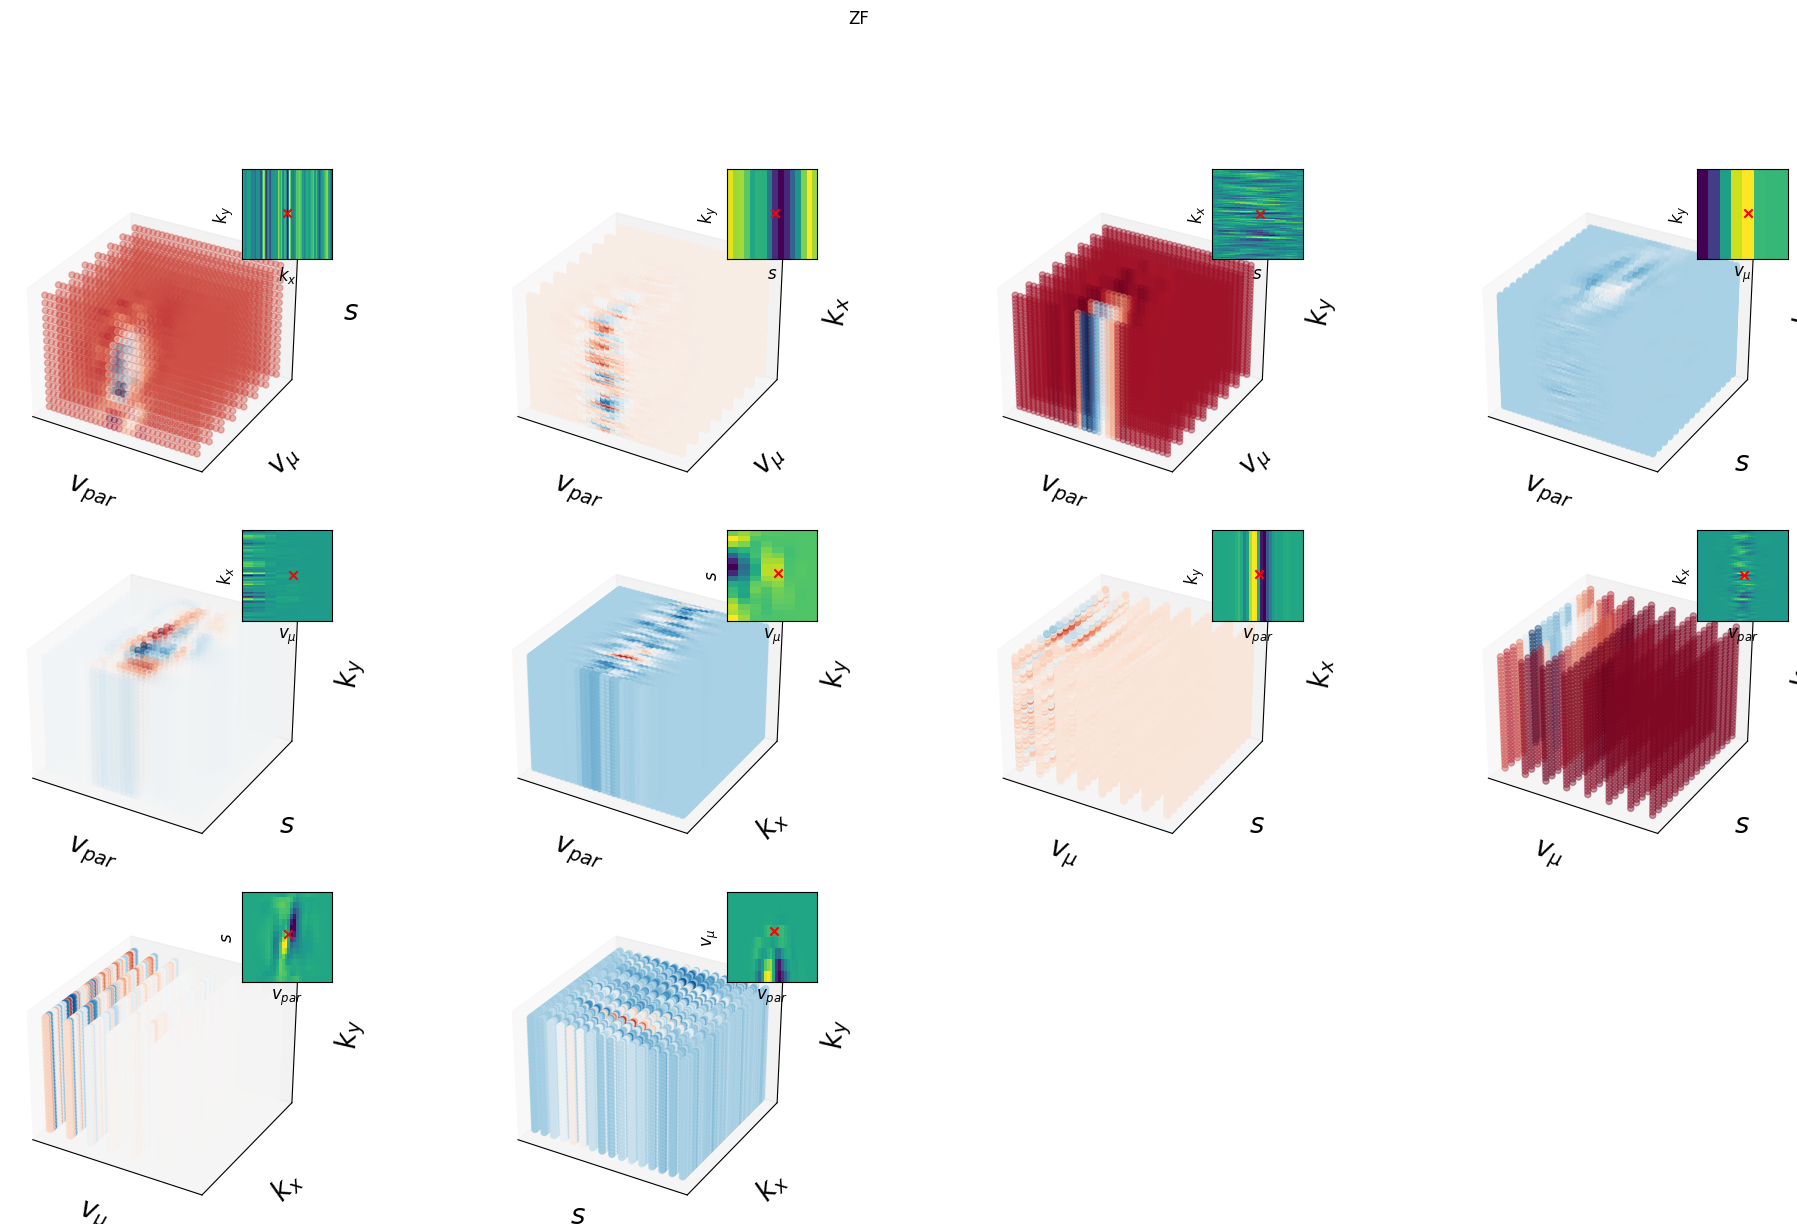

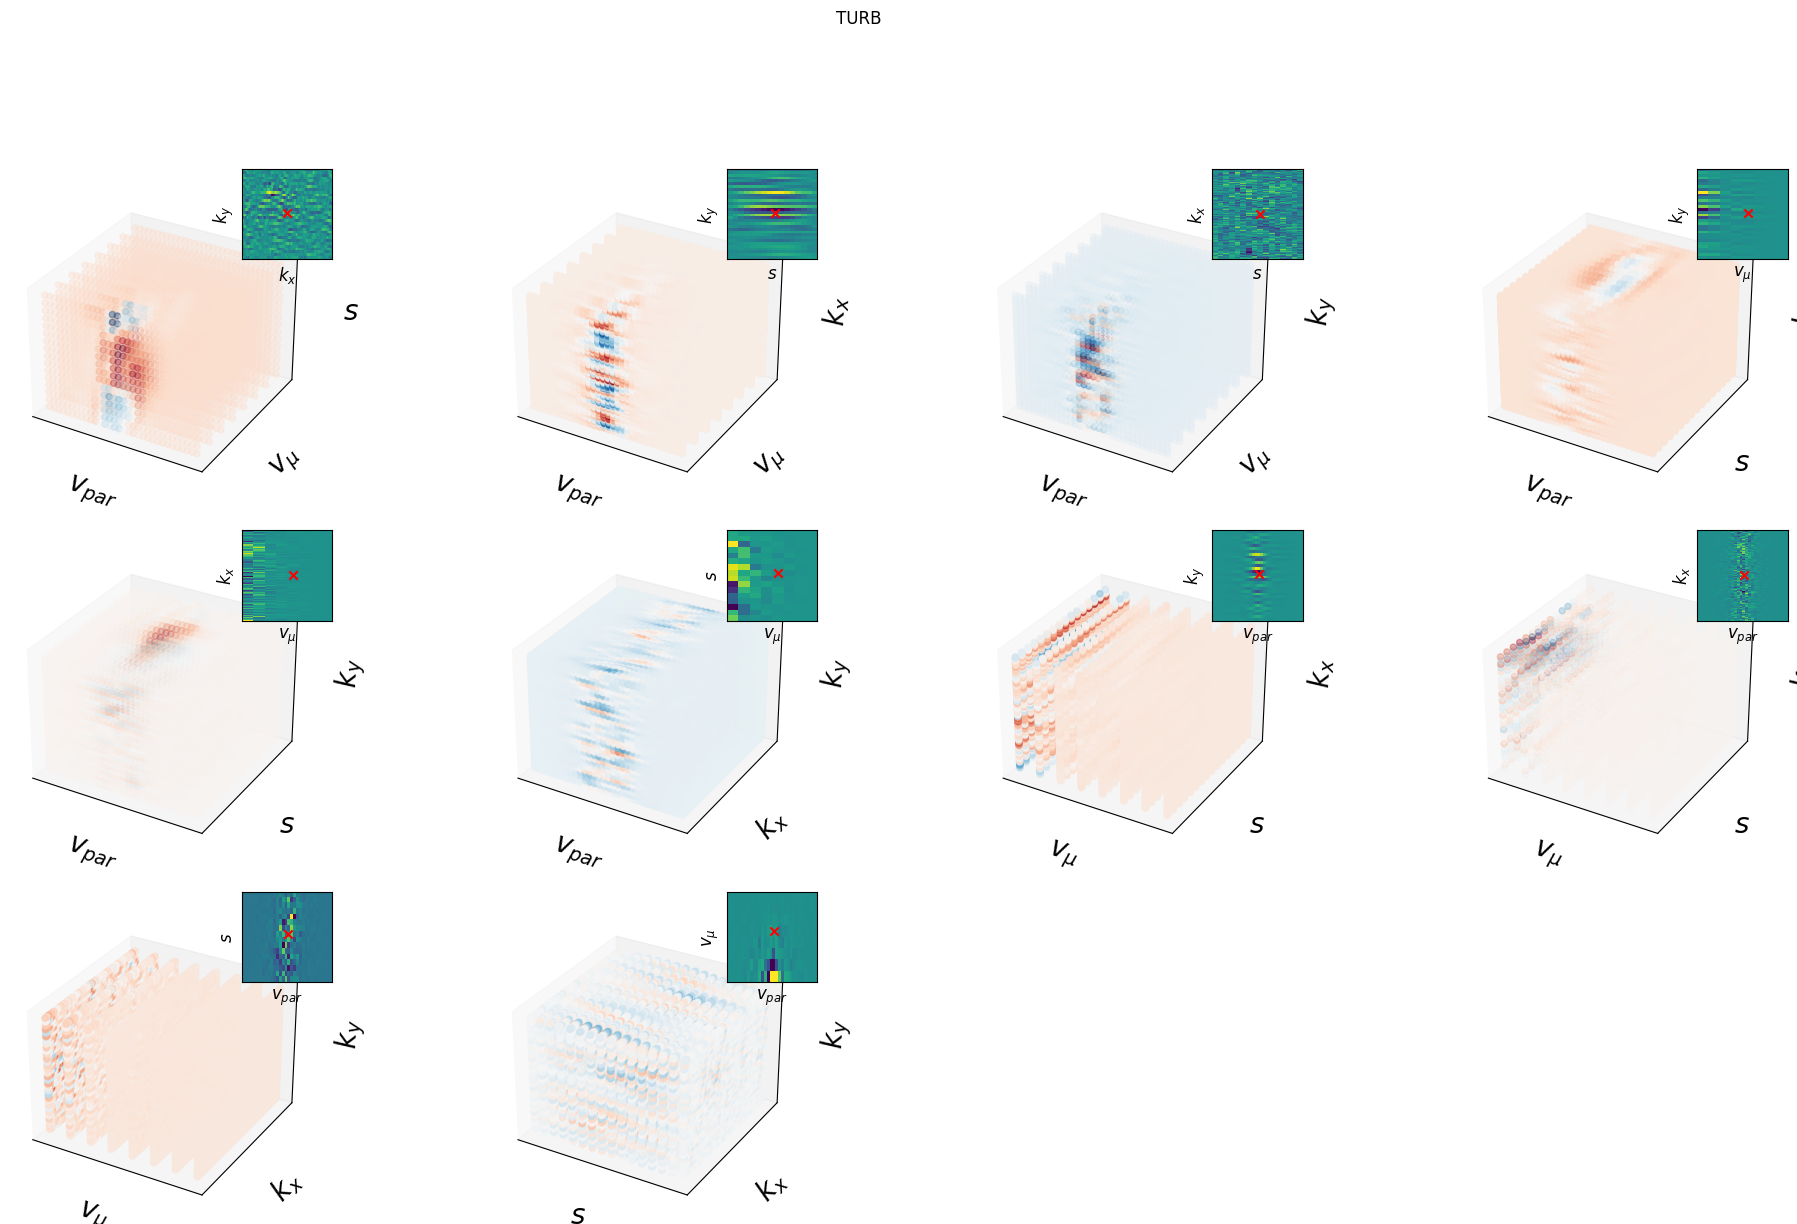

In [236]:
stuff("K50", mode="slice")

In [263]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def velocity_space_sample_3D(x, title=""):
    labels = [r"v_{par}", r"v_{\mu}", r"s", r"k_x", r"k_y"]

    fig = plt.figure(figsize=(20, 20))
    fig.suptitle(title)

    fixed_axes = (2, 3, 4)
    slice_axes = (0, 1)

    global_min = np.inf
    global_max = -np.inf

    npar, nmu = 8, 2
    slice_idx = [
        [int(v_par), int(v_mu)]
        for v_par in np.linspace(9, 23, npar)
        for v_mu in np.linspace(1, 3, nmu)
    ]

    for idx in range(16):
        slice_point_0, slice_point_1 = slice_idx[idx]
        xx = x[slice_point_0, slice_point_1, :, :, :].numpy()
        global_min = min(global_min, xx.min())
        global_max = max(global_max, xx.max())

    cmap = "RdBu_r"

    for idx in range(16):
        ax_main = fig.add_subplot(4, 4, idx + 1, projection="3d")

        slice_point_0, slice_point_1 = slice_idx[idx]
        xx = x[slice_point_0, slice_point_1, :, :, :].numpy()

        ax_imshow = inset_axes(
            ax_main, width="30%", height="30%", loc="upper right", borderpad=-2.5
        )
        sliced_dims = x.mean(fixed_axes).T
        ax_imshow.matshow(sliced_dims, cmap="viridis", origin="lower")
        ax_imshow.scatter(slice_point_0, slice_point_1, color="red", marker="x")
        ax_imshow.set_xticks([])
        ax_imshow.set_yticks([])
        ax_imshow.grid(False)
        force_aspect(ax_imshow)

        X, Y, Z = np.meshgrid(
            np.arange(xx.shape[0]),
            np.arange(xx.shape[1]),
            np.arange(xx.shape[2]),
            indexing="ij",
        )

        scatter = ax_main.scatter(
            X.flatten(),
            Y.flatten(),
            Z.flatten(),
            c=xx.flatten(),
            cmap=cmap,
            alpha=0.4,
            vmin=global_min,
            vmax=global_max,
        )

        ax_main.set_xlabel(rf"${labels[fixed_axes[0]]}$", fontsize=20)
        ax_main.set_ylabel(rf"${labels[fixed_axes[1]]}$", fontsize=20)
        ax_main.set_zlabel(rf"${labels[fixed_axes[2]]}$", fontsize=20)

        ax_main.set_xticks([])
        ax_main.set_yticks([])
        ax_main.set_zticks([])
        ax_main.grid(False)

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(scatter, cax=cbar_ax)

    return fig

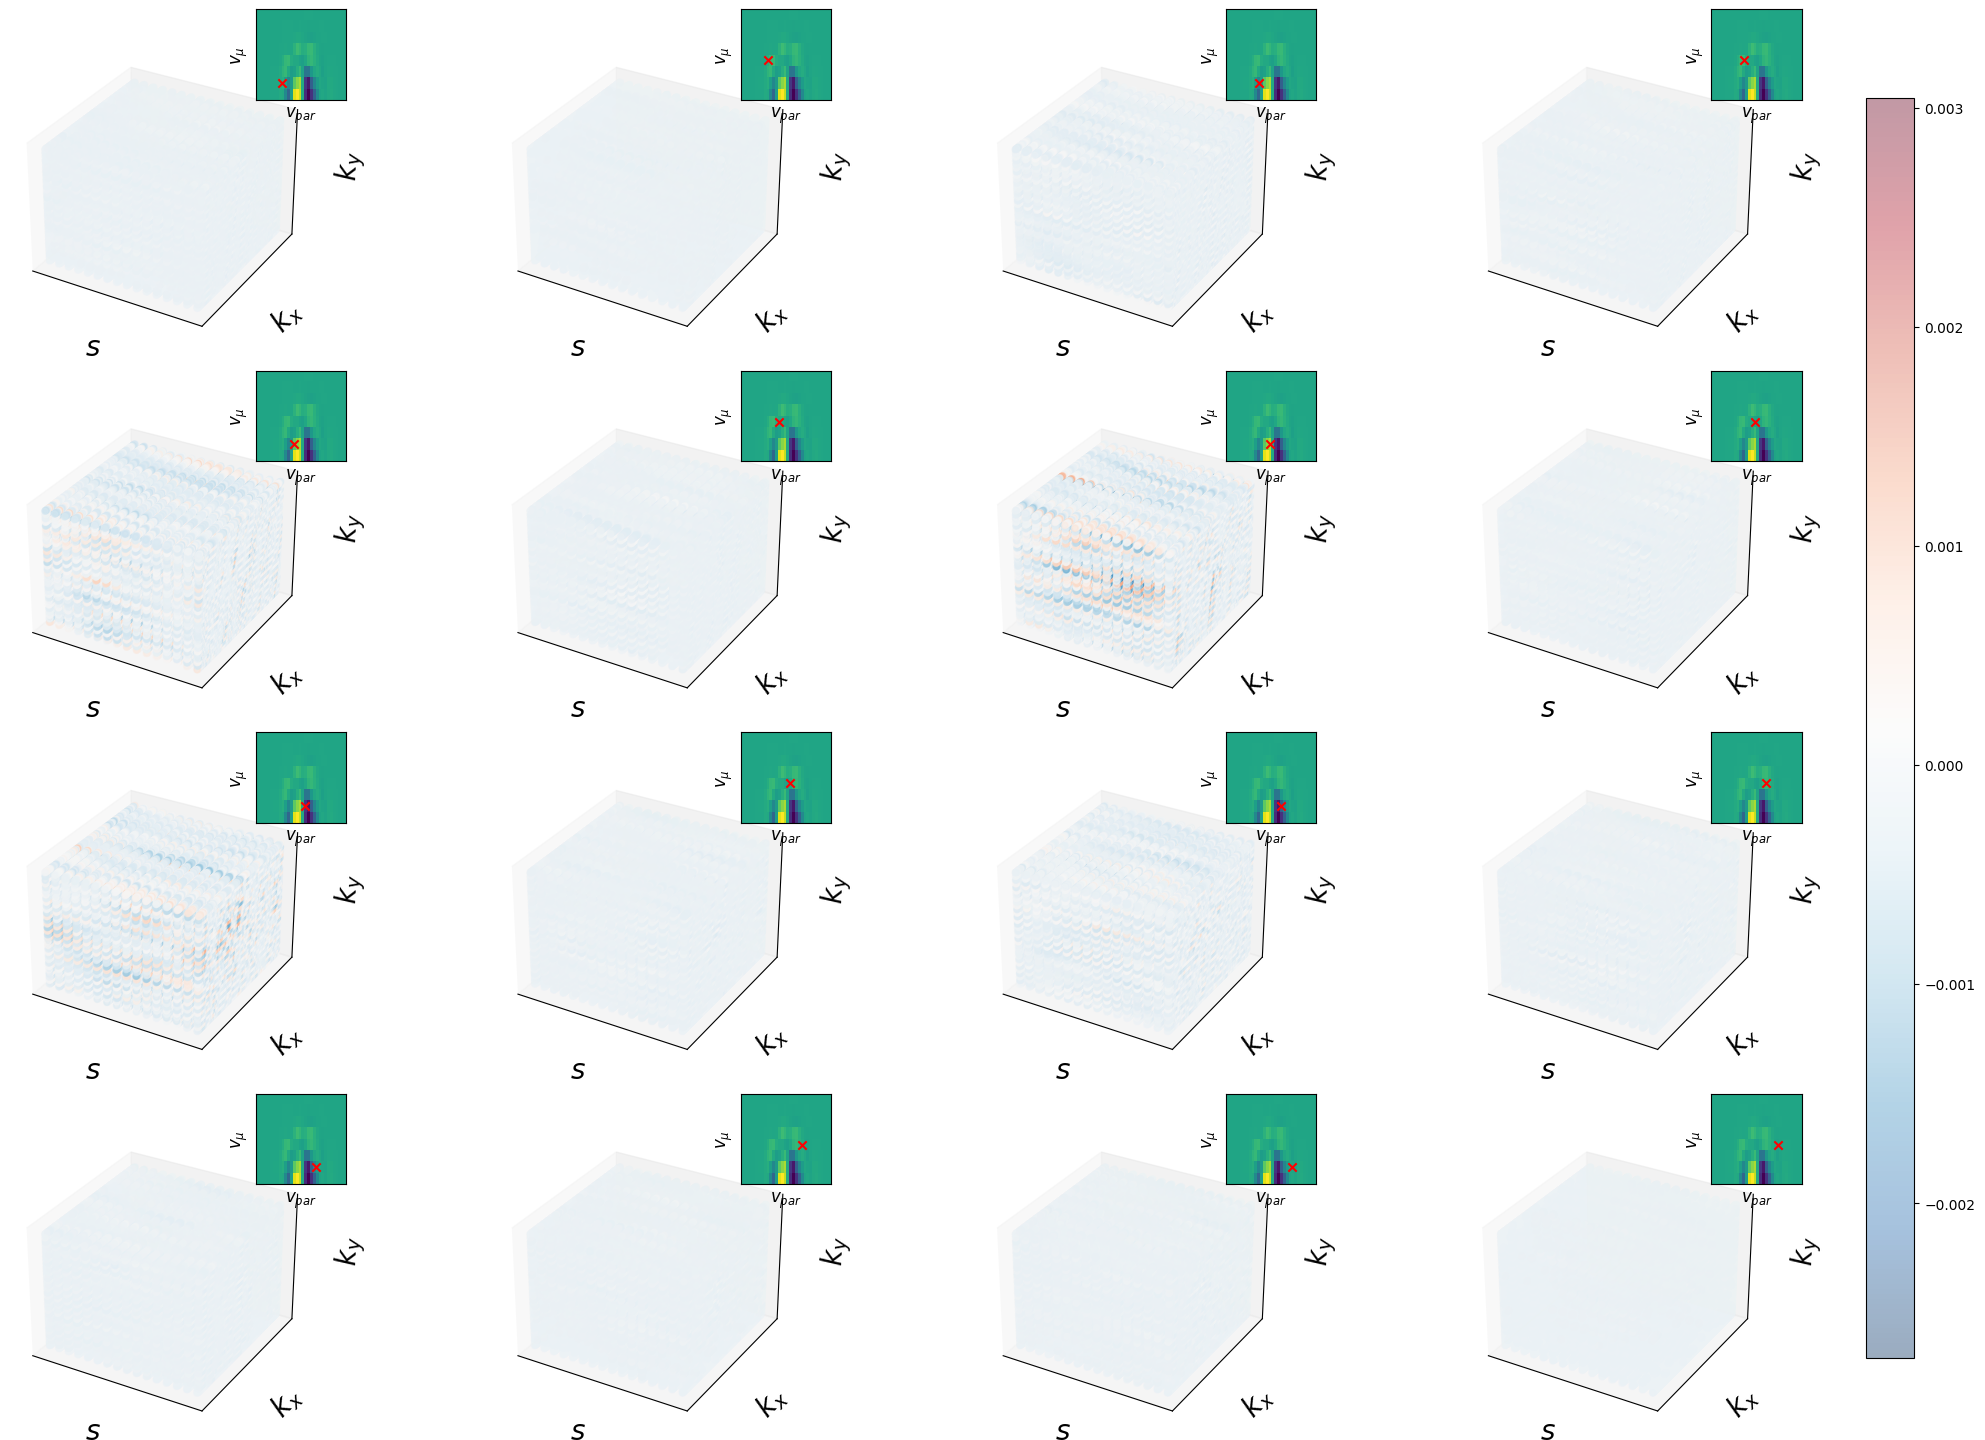

In [264]:
sgrid = np.loadtxt(os.path.join(directory, "sgrid"))
krho = np.loadtxt(os.path.join(directory, "krho"))
vpgr = np.loadtxt(os.path.join(directory, "vpgr.dat"))
ns = sgrid.shape[1] if len(sgrid.shape) > 1 else sgrid.shape[0]

nkx, nky = krho.shape[1], krho.shape[0]
nvpar, nmu = vpgr.shape[1], vpgr.shape[0]

with open(os.path.join(directory, "K70"), "rb") as fid:
    ff = np.fromfile(fid, dtype=np.float64)

x = np.reshape(ff, (2, nvpar, nmu, ns, nkx, nky), order="F").copy().astype("float32")


def do_ifft(x):
    x = np.ascontiguousarray(np.moveaxis(x, 0, -1))
    x = x.view(dtype=np.complex64)
    x = np.fft.fftshift(x, axes=(3, 4))
    x = np.fft.ifftn(x, axes=(3, 4))
    x = np.stack([x.real, x.imag]).squeeze().astype("float32")
    return torch.from_numpy(x)


x = do_ifft(x.copy())

_ = velocity_space_sample_3D(x[0])

[9.7665754e-05 9.7651216e-05] [1.11109193e-05 1.10323535e-05]


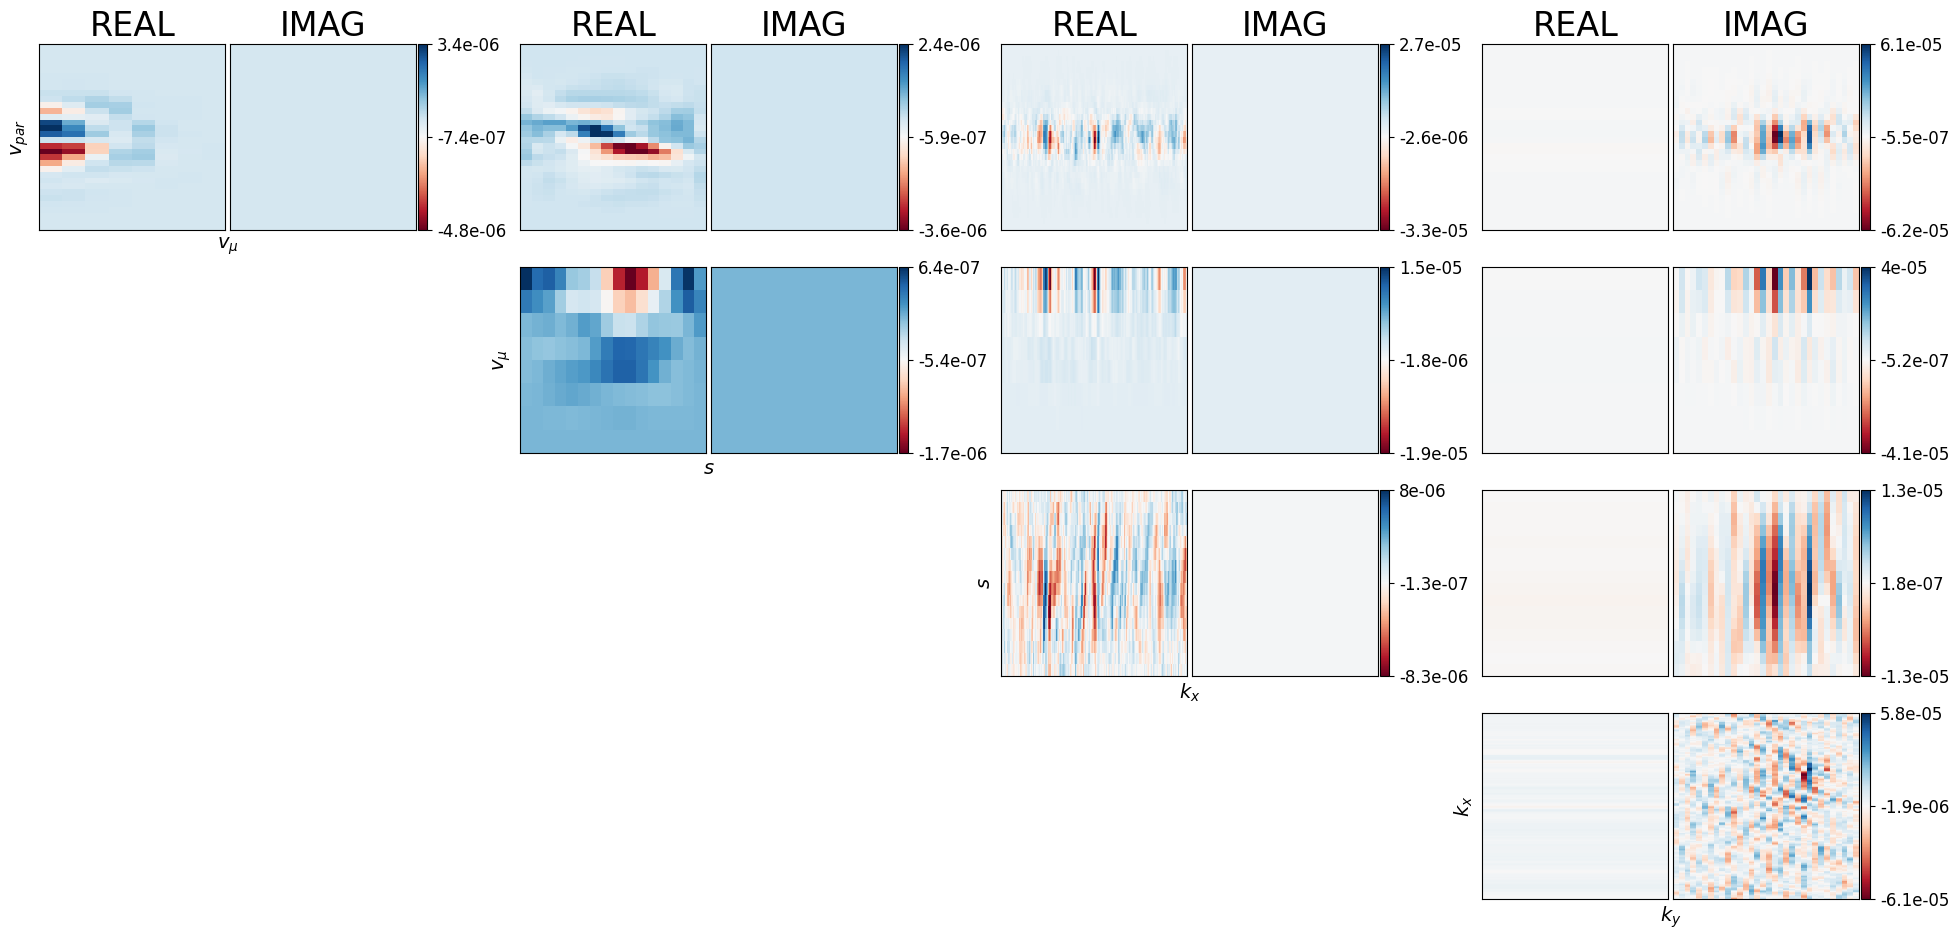

In [ ]:
_ = fourier_normalizations("K50", mode="mean", fft_norm=None)

## Model visualization

In [65]:
CKP = "/system/user/publicwork/fpaische/plasmamodelling/outputs/20250115_150422"
device = "cuda"

In [ ]:
import yaml
from omegaconf import OmegaConf

from models import get_model

from dataset.cyclone import CycloneDataset

cfg = OmegaConf.create(yaml.safe_load(open(f"{CKP}/config.yaml", "r")))

cfg.model.swin.itg_conditioning = False

data = CycloneDataset(
    active_keys=cfg.dataset.active_keys,
    split="val",
    random_seed=cfg.seed,
    normalization=cfg.dataset.normalization,
    spatial_ifft=cfg.dataset.spatial_ifft,
    bundle_seq_length=cfg.model.bundle_seq_length,
    trajectories=cfg.dataset.validation_trajectories,
)
traindata = []
print(f"Train: {len(traindata)}, Val: {len(data)}")

model = get_model(cfg, data)

loaded_ckp = torch.load(f"{CKP}/best.pth", map_location=device, weights_only=True)
model.load_state_dict(
    {k.replace("module.", ""): v for k, v in loaded_ckp["model_state_dict"].items()}
)

model = model.to(device)

In [ ]:
from tqdm import tqdm
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt


def mse_time_histogram(model_fn, data):
    model_fn.eval()

    losses = defaultdict(list)
    sample = data[0]
    K1 = sample.x.numpy()
    x = torch.tensor(K1).to(device).unsqueeze(0)
    with torch.no_grad():
        for idx in tqdm(range(len(data))):
            sample = data[idx]
            K2 = sample.y.numpy()
            # x = torch.tensor(K1).to(device).unsqueeze(0)
            ts = sample.timestep_index.to(device).unsqueeze(0)
            x = model_fn(x, timestep=ts)

            mse = np.mean((x.squeeze(0).cpu().detach().numpy() - K2) ** 2)
            losses[ts.squeeze().item()].append(mse)

    fig = mse_time_histogram_from_losses(losses)

    return fig, losses


def mse_time_histogram_from_losses(losses):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    times = sorted(losses.keys())
    losses_mean = [np.mean(losses[t]) for t in times]
    losses_std = [np.std(losses[t]) for t in times]

    # Bar plot with error bars
    ax.bar(times, losses_mean, yerr=losses_std, alpha=0.7, capsize=5, color="blue")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Mean Squared Error")
    ax.set_title("MSE by Time Step")
    ax.grid(True)

    return fig

In [ ]:
_, losses = mse_time_histogram(model, data=traindata)

In [ ]:
_, val_losses = mse_time_histogram(model, data=data)

In [ ]:
_ = mse_time_histogram_from_losses(losses | val_losses)

In [ ]:
def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def distribution_5D(model_fn, idx=0):
    labels = ["vpar", "mu", "s", "x", "y"]

    model_fn.eval()
    sample = traindata[idx]
    K2 = sample.y.numpy()
    x = sample.x.to(device).unsqueeze(0)
    ts = sample.timestep_index.to(device).unsqueeze(0)
    f = model_fn(x, timestep=ts).squeeze(0).cpu().detach().numpy()

    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(20, 20))
    c_map = colormaps["rainbow"]
    c_map.set_bad("k")

    imin = -1
    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])
        xx = f[0].std(other)
        xx[xx == 0] = np.nan
        ax[i, j].matshow(xx, cmap=c_map)

        if i > imin:
            ax[i, j].set_ylabel(labels[i], fontsize=20)
            ax[i, j].set_xlabel(labels[j], fontsize=20)
            imin = i

        force_aspect(ax[i, j])

    for i in range(5):
        for j in range(5):
            if [i, j] not in comb:
                ax[i, j].remove()
    return fig

In [ ]:
fig = distribution_5D(model, 10)
# fig

In [ ]:
fig

In [ ]:
from matplotlib import animation


def animate_5D(model_fn, title="", frames=10, start=55, idx=0):
    plt.rcParams["animation.html"] = "jshtml"
    plt.ioff()
    plt.gca().set_aspect("equal")

    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    fig.tight_layout()
    fig.suptitle(title)

    model_fn.eval()
    sample = traindata[idx]
    K1 = sample.x.numpy()
    K2 = sample.y.numpy()
    x = torch.tensor(K1).to(device).unsqueeze(0)
    f = model_fn(x).squeeze(0).cpu().detach().numpy()

    gt_vmax, gt_vmin = K2[0, :, 7, :, 85, :].max(), K2[0, :, 7, :, 85, :].min()
    pred_vmax, pred_vmin = f[0, :, 7, :, 85, :].max(), f[0, :, 7, :, 85, :].min()

    # Initial plots to set up the colorbars
    gt_im = ax[0].matshow(K2[0, start, 7, :, 85, :], vmax=gt_vmax, vmin=gt_vmin)
    pred_im = ax[1].matshow(f[0, start, 7, :, 85, :], vmax=pred_vmax, vmin=pred_vmin)

    # Adding colorbars
    cbar_gt = fig.colorbar(
        gt_im, ax=ax[0], orientation="vertical", fraction=0.046, pad=0.04
    )
    cbar_gt.set_label("Ground Truth", fontsize=12)

    cbar_pred = fig.colorbar(
        pred_im, ax=ax[1], orientation="vertical", fraction=0.046, pad=0.04
    )
    cbar_pred.set_label("Prediction", fontsize=12)

    def animate(t):
        gt3 = K2[0, start + t, 7, :, 85, :]
        pred3 = f[0, start + t, 7, :, 85, :]

        gt_im.set_array(gt3)
        pred_im.set_array(pred3)

    return animation.FuncAnimation(fig, animate, frames=frames)

In [ ]:
ani = animate_5D(model, "", frames=32, start=0, idx=0)
ani

In [ ]:
writer = animation.PillowWriter(fps=8, bitrate=400)
ani.save("shift2.gif", writer=writer)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import animation


def animate_5D2(model_fn, title="", frames=10, start=55, idx=0):
    labels = ["vpar", "mu", "s", "x", "y"]

    plt.rcParams["animation.html"] = "jshtml"
    plt.ioff()
    plt.gca().set_aspect("equal")

    fig, ax = plt.subplots(2, 5, figsize=(15, 10))
    fig.tight_layout()
    fig.suptitle(title)

    model_fn.eval()
    sample = data[idx]
    K1 = sample.x.numpy()
    K2 = sample.y.numpy()
    x = torch.tensor(K1).to(device).unsqueeze(0)
    f = model_fn(x).squeeze(0).cpu().detach().numpy()

    # Compute limits for each subplot
    gt_limits = {
        "vpar": (K2[:, :, 0, :, 85, :].max(), K2[:, :, 0, :, 85, :].min()),
        "mu": (K2[:, 0, :, :, 85, :].max(), K2[:, 0, :, :, 85, :].min()),
        "s": (K2[:, :, :, :, 85, :].max(), K2[:, :, :, :, 85, :].min()),
        "x": (K2[:, :, :, :, 85, :].max(), K2[:, :, :, :, 85, :].min()),
        "y": (K2[:, :, :, :, :, :].max(), K2[:, :, :, :, :, :].min()),
    }
    pred_limits = {
        "vpar": (f[:, :, 0, :, 85, :].max(), f[:, :, 0, :, 85, :].min()),
        "mu": (f[:, 0, :, :, 85, :].max(), f[:, 0, :, :, 85, :].min()),
        "s": (f[:, :, :, :, 85, :].max(), f[:, :, :, :, 85, :].min()),
        "x": (f[:, :, :, :, 85, :].max(), f[:, :, :, :, 85, :].min()),
        "y": (f[:, :, :, :, :, :].max(), f[:, :, :, :, :, :].min()),
    }

    # Initialize matshow and colorbars
    ims = []
    cbars = []
    for row in range(2):
        for col in range(5):
            label = labels[col]
            vmin, vmax = gt_limits[label] if row == 0 else pred_limits[label]
            im = ax[row, col].matshow(
                K2[0, 0, 0, :, 85, :] if row == 0 else f[0, 0, 0, :, 85, :],
                vmin=vmin,
                vmax=vmax,
            )
            ims.append(im)
            cbar = fig.colorbar(
                im, ax=ax[row, col], orientation="vertical", fraction=0.046, pad=0.04
            )
            cbar.set_label(
                f"{label} ({'Ground Truth' if row == 0 else 'Prediction'})", fontsize=12
            )
            cbars.append(cbar)

            # Set labels
            ax[row, col].set_xlabel(label, fontsize=15)
            ax[row, col].set_ylabel("s" if col == 2 else "y", fontsize=15)

    def animate(t):
        if start + t < K2.shape[2]:
            ims[0].set_array(K2[0, :, 0, start + t, 85, :])
            ims[5].set_array(f[0, :, 0, start + t, 85, :])

        if start + t < K2.shape[3]:
            ims[1].set_array(K2[0, 0, :, start + t, 85, :])
            ims[6].set_array(f[0, 0, :, start + t, 85, :])

        if start + t < K2.shape[0]:
            ims[2].set_array(K2[0, start + t, 0, :, 85, :])
            ims[7].set_array(f[0, start + t, 0, :, 85, :])

        if start + t < K2.shape[-1]:
            ims[3].set_array(K2[0, :, 0, :, 85, start + t])
            ims[8].set_array(f[0, :, 0, :, 85, start + t])

        ims[4].set_array(K2[0, 0, 0, :, start + t, :])
        ims[9].set_array(f[0, 0, 0, :, start + t, :])

    return animation.FuncAnimation(fig, animate, frames=frames)

In [ ]:
ani = animate_5D2(model, "", frames=5, start=0)
ani

In [ ]:
writer = animation.PillowWriter(fps=4, bitrate=400)
ani.save("big_ani.gif", writer=writer)

In [ ]:
def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def plot4x4(f, title="", mark_bad=False):
    labels = ["vpar", "mu", "s", "x", "y"]
    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(20, 20))
    fig.suptitle(title)
    c_map = colormaps["coolwarm"]
    c_map.set_bad("k")

    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])
        xx = f[0].mean(other)
        if mark_bad:
            xx_std = f[0].std(other)
            xx[xx_std == 0] = np.nan

        im00 = ax[i, j].imshow(xx.T, cmap=c_map)

        fig.colorbar(im00, ax=ax[i, j])
        ax[i, j].set_xlabel(labels[i])
        ax[i, j].set_ylabel(labels[j])
        force_aspect(ax[i, j])

    for i in range(5):
        for j in range(5):
            if [i, j] not in comb:
                ax[i, j].remove()
    return fig

In [ ]:
model.eval()
K1, _, K2, _ = data[10]
K1 = K1.numpy()
K2 = K2.numpy()
x = torch.tensor(K1).to(device).unsqueeze(0)
f = model(x).squeeze(0).cpu().detach().numpy()

# f = np.zeros_like(f)

mse = K2 - f

plot4x4(K2, "GT")

In [ ]:
plot4x4(f, f"PRED (MSE = {mse.mean():.4f})")

In [ ]:
plot4x4(mse, f"MSE = {mse.mean():.4f}")

In [67]:
from matplotlib import colormaps


def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def plot4x4_sided(x1, x2, title="", mark_bad=False):
    labels = ["vpar", "mu", "s", "x", "y"]
    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(30, 12))
    for i in range(5):
        for j in range(5):
            ax[i, j].remove()

    fig.tight_layout()
    fig.suptitle(title)
    c_map = colormaps["coolwarm"]
    c_map.set_bad("k")

    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])
        x1_plot = x1[0].mean(other)
        x2_plot = x2[0].mean(other)
        x1_vmax, x1_vmin = x1_plot.max(), x1_plot.min()
        x2_vmax, x2_vmin = x2_plot.max(), x2_plot.min()

        if mark_bad:
            x1_std = x1.std(other)
            x2_std = x2.std(other)
            x1_plot[x1_std == 0] = np.nan
            x2_plot[x2_std == 0] = np.nan

        # Clear the axis and directly plot two images side by side
        ax_ij = ax[i, j]
        # ax_ij.clear()

        # Get the position of the original axis
        pos = ax_ij.get_position()

        # Create two new axes within the same space as the original subplot
        width = pos.width / 2  # Split the width into two halves
        ax1 = fig.add_axes([pos.x0, pos.y0, width, pos.height])
        ax2 = fig.add_axes([pos.x0 + width, pos.y0, width, pos.height])

        # Plot x1 and xp side by side
        im1 = ax1.imshow(x1_plot, cmap=c_map, vmax=x1_vmax, vmin=x1_vmin)
        im2 = ax2.imshow(x2_plot, cmap=c_map, vmax=x2_vmax, vmin=x2_vmin)

        fig.colorbar(im1, ax=ax1)
        fig.colorbar(im2, ax=ax2)

        if i == 0:
            # Set axis labels
            ax1.set_title("GT")
            ax2.set_title("PRED")

        ax1.set_xlabel(labels[i])
        ax1.set_ylabel(labels[j])
        ax2.set_xlabel(labels[i])
        ax2.set_ylabel(labels[j])

        # Force aspect ratio
        force_aspect(ax1)
        force_aspect(ax2)

    return fig

In [ ]:
model.eval()
sample = data[0]
K1 = sample.x.numpy()
K2 = sample.y.numpy()
x = torch.tensor(K1).to(device).unsqueeze(0)
ts = sample.timestep_index.to(device).unsqueeze(0)
model = model.cpu()
f = model.patch_decode(*model.patch_encode(x.cpu())).squeeze(0).cpu().detach().numpy()

fig = plot4x4_sided(K1, f)

In [ ]:
fig

In [ ]:
model.eval()
sample = data[1]
K1 = sample.x.numpy()
K2 = sample.y.numpy()
x = torch.tensor(K1).to(device).unsqueeze(0)
ts = sample.timestep_index.to(device).unsqueeze(0)
f = model.cpu()(x.cpu(), timestep=ts.cpu()).squeeze(0).cpu().detach().numpy()

fig = plot4x4_sided(K1, K2)

In [ ]:
model.eval()
sample = data[2]
K1 = sample.x.numpy()
K2 = sample.y.numpy()
x = torch.tensor(K1).to(device).unsqueeze(0)
ts = sample.timestep_index.to(device).unsqueeze(0)
f = model.cpu()(x.cpu(), timestep=ts.cpu()).squeeze(0).cpu().detach().numpy()

fig = plot4x4_sided(K1, K2)

In [ ]:
from matplotlib import animation


def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def plot4x4_animate(model_fn, title="", mark_bad=False, frames=5, start_idx=0):
    plt.rcParams["animation.html"] = "jshtml"
    plt.ioff()

    labels = ["vpar", "mu", "s", "x", "y"]
    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(30, 12))
    for i in range(5):
        for j in range(5):
            ax[i, j].remove()

    # fig.tight_layout()
    fig.suptitle(title)
    c_map = colormaps["coolwarm"]
    c_map.set_bad("k")

    model.eval()

    x0 = data[start_idx].x
    preds = []
    preds = [x0.to(device).unsqueeze(0)]
    with torch.no_grad():
        for i in range(frames):
            xp = model_fn(preds[-1])
            preds.append(xp)

    preds = preds[1:]
    preds = [p.squeeze(0).cpu().detach().numpy() for p in preds]

    def animate(t):
        x1 = data[start_idx + t].y.numpy()
        xp = preds[t]
        ts = data[start_idx + t].timestep.numpy().item()
        fig.suptitle(f"ts={ts:.2f}", fontsize=30)

        for i, j in comb:
            other = tuple([o for o in range(5) if o != i and o != j])

            x1_plot = x1[0].mean(other)
            xp_plot = xp[0].mean(other)
            x1_vmax, x1_vmin = x1_plot.max(), x1_plot.min()
            xp_vmax, xp_vmin = xp_plot.max(), xp_plot.min()

            if mark_bad:
                x1_std = x1.std(other)
                xp_std = xp.std(other)
                x1_plot[x1_std == 0] = np.nan
                xp_plot[xp_std == 0] = np.nan

            # Clear the axis and directly plot two images side by side
            ax_ij = ax[i, j]
            # ax_ij.clear()

            # Get the position of the original axis
            pos = ax_ij.get_position()

            # Create two new axes within the same space as the original subplot
            width = pos.width / 2  # Split the width into two halves
            ax1 = fig.add_axes([pos.x0, pos.y0, width, pos.height])
            ax2 = fig.add_axes([pos.x0 + width, pos.y0, width, pos.height])

            # Plot x1 and xp side by side
            im1 = ax1.imshow(x1_plot, cmap=c_map, vmax=x1_vmax, vmin=x1_vmin)
            im2 = ax2.imshow(xp_plot, cmap=c_map, vmax=xp_vmax, vmin=xp_vmin)

            if i == 0:
                # Set axis labels
                ax1.set_title("GT")
                ax2.set_title("PRED")
            ax1.set_xlabel(labels[i])
            ax1.set_ylabel(labels[j])
            ax2.set_xlabel(labels[i])
            ax2.set_ylabel(labels[j])

            # Force aspect ratio
            force_aspect(ax1)
            force_aspect(ax2)

    return animation.FuncAnimation(fig, animate, frames=frames)

In [ ]:
ani = plot4x4_animate(model, frames=10, start_idx=0)
ani

In [ ]:
writer = animation.PillowWriter(fps=1, bitrate=600)
ani.save("sided.gif", writer=writer)